In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"space_mission_data.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [2]:
df["Price_orignal"]=df["Price"]

In [3]:
df["Price"]=(df["Price"].astype(str).str.replace(",","",regex=False))
df["Price"]=pd.to_numeric(df["Price"],errors="coerce")
df["Price"].describe()

count     964.000000
mean      153.792199
std       288.450732
min         5.300000
25%        40.000000
50%        62.000000
75%       164.000000
max      5000.000000
Name: Price, dtype: float64

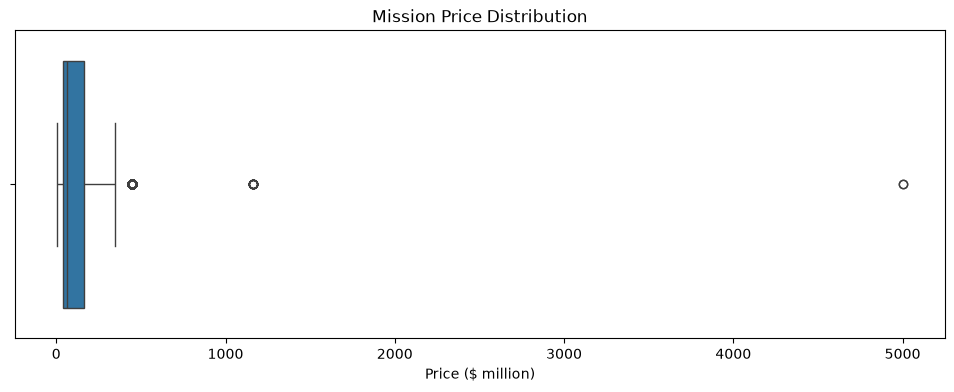

In [4]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df["Price"])
plt.xlabel("Price ($ million)")
plt.title("Mission Price Distribution")
plt.show()

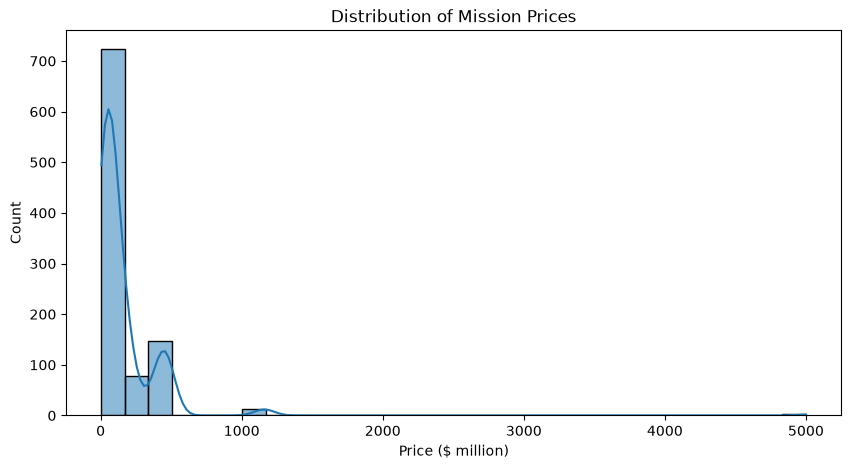

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"].dropna(), bins=30, kde=True)
plt.xlabel("Price ($ million)")
plt.title("Distribution of Mission Prices")
plt.show()

In [6]:

from datetime import datetime, timedelta
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    errors="coerce",
    utc=True
)

df["Year"] = df["Date"].dt.year

df["Decade"] = (df["Year"] // 10) * 10
df[["Date", "Year", "Decade"]].head()

,Date,Year,Decade
0,2020-08-07 05:12:00+00:00,2020,2020
1,2020-08-06 04:01:00+00:00,2020,2020
2,2020-08-04 23:57:00+00:00,2020,2020
3,2020-07-30 21:25:00+00:00,2020,2020
4,2020-07-30 11:50:00+00:00,2020,2020


In [7]:
df.groupby("Decade")["Price"].agg(
    ["count", "median"]
)

,count,median
Decade,,
1950,0,NaN
1960,33,59.00
1970,6,1160.00
1980,44,450.00
1990,132,136.60
2000,210,69.70
2010,487,62.00
2020,52,49.25


*Mission prices vary considerably across decades, suggesting that time period is an important factor when estimating missing prices. However, some decades have very few known prices, so decade alone may not be reliable for imputation.*

In [8]:
df.groupby("Organisation")["Price"].agg(
    ["count", "median"]
).sort_values("count", ascending=False)

,count,median
Organisation,,
CASC,158,30.8
NASA,149,450.0
SpaceX,99,56.5
ULA,98,123.0
Arianespace,96,200.0
Northrop,83,40.0
ISRO,67,31.0
MHI,37,90.0
VKS RF,33,41.8


*Mission prices vary considerably across organizations. Organizations such as NASA, Arianespace, ULA, SpaceX, CASC and ISRO have noticeably different median prices, suggesting that organization is an important factor for price estimation. However, organizations with very few known prices have unreliable medians, so organization alone may not always be sufficient.*

In [9]:
overall_median = df["Price"].median()

print(overall_median)

62.0


In [10]:
org_median = df.groupby("Organisation")["Price"].transform("median")
org_median

0         56.5
1         30.8
2         56.5
3         48.5
4        123.0
         ...  
4319       NaN
4320       NaN
4321       NaN
4322    5000.0
4323    5000.0
Name: Price, Length: 4324, dtype: float64

In [11]:
org_median.head(10)

0     56.5
1     30.8
2     56.5
3     48.5
4    123.0
5     30.8
6     48.5
7     30.8
8     56.5
9     39.0
Name: Price, dtype: float64

In [12]:
org_decade_median = (
    df.groupby(["Organisation", "Decade"])["Price"]
      .transform("median")
)
org_decade_median.head(10)

0     50.00
1     29.75
2     50.00
3     48.50
4    132.50
5     29.75
6     48.50
7     29.75
8     50.00
9     90.00
Name: Price, dtype: float64

*Instead of asking "What does this organization usually cost?", we're asking "What does this organization usually cost during this particular decade?"*

In [13]:
known = df[df["Price"].notna()].copy()

known.shape

(964, 12)

In [14]:
test = known.sample(frac=0.2, random_state=42)
test

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Price_orignal,Year,Decade
1253,1253,1253,CASC,"LC-7, Taiyuan Satellite Launch Center, China",1999-05-10 01:33:00+00:00,Long March 4B | Fengyun 1C & Shijian-5,StatusActive,64.68,Success,64.68,1999,1990
1877,1877,1877,NASA,"LC-39B, Kennedy Space Center, Florida, USA",1989-08-08 12:37:00+00:00,Space Shuttle Columbia | STS-28R,StatusRetired,450.00,Success,450.0,1989,1980
3595,3595,3595,US Air Force,"SLC-4W, Vandenberg AFB, California, USA",1969-01-22 19:10:00+00:00,Titan IIIB | OPS 7585,StatusRetired,59.00,Success,59.0,1969,1960
2104,2104,2104,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1985-10-03 15:15:00+00:00,Space Shuttle Atlantis | STS-51-J,StatusRetired,450.00,Success,450.0,1985,1980
879,879,879,SpaceX,"Omelek Island, Ronald Reagan Ballistic Missile...",2007-03-21 01:10:00+00:00,Falcon 1 | DemoSat,StatusRetired,7.00,Failure,7.0,2007,2000
...,...,...,...,...,...,...,...,...,...,...,...,...
760,760,760,Kosmotras,"Site 109/95, Baikonur Cosmodrome, Kazakhstan",2009-07-29 18:46:00+00:00,Dnepr | DubaiSat 1 & Others,StatusRetired,29.00,Success,29.0,2009,2000
1408,1408,1408,NASA,"LC-39B, Kennedy Space Center, Florida, USA",1997-01-12 09:27:00+00:00,Space Shuttle Atlantis | STS-81,StatusRetired,450.00,Success,450.0,1997,1990
40,40,40,Arianespace,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",2020-03-21 17:06:00+00:00,Soyuz 2.1b/Fregat | OneWeb #3,StatusActive,48.50,Success,48.5,2020,2020
38,38,38,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-03-26 20:18:00+00:00,Atlas V 551 | AEHF 6,StatusActive,153.00,Success,153.0,2020,2020


In [15]:
actual = test["Price"]
actual

1253     64.68
1877    450.00
3595     59.00
2104    450.00
879       7.00
         ...  
760      29.00
1408    450.00
40       48.50
38      153.00
1096     64.68
Name: Price, Length: 193, dtype: float64

In [16]:
pred_overall = pd.Series(
    overall_median,
    index=test.index
)
pred_overall

1253    62.0
1877    62.0
3595    62.0
2104    62.0
879     62.0
        ... 
760     62.0
1408    62.0
40      62.0
38      62.0
1096    62.0
Length: 193, dtype: float64

In [17]:
from sklearn.metrics import mean_absolute_error
mae_overall = mean_absolute_error(
    actual,
    pred_overall
)

print("Overall Median MAE:", mae_overall)

Overall Median MAE: 116.01512953367876


In [18]:
train = known.drop(test.index)
org_medians = train.groupby("Organisation")["Price"].median()

pred_org = test["Organisation"].map(org_medians)

pred_org = pred_org.fillna(train["Price"].median())

mae_org = mean_absolute_error(
    actual,
    pred_org
)

print("Organisation Median MAE:", mae_org)

Organisation Median MAE: 20.092331606217616


In [19]:
org_decade_medians = (
    train.groupby(["Organisation", "Decade"])["Price"]
    .median()
)

pred_org_decade = test.set_index(
    ["Organisation", "Decade"]
).index.map(org_decade_medians)

pred_org_decade = pd.Series(
    pred_org_decade,
    index=test.index,
    dtype="float64"
)

pred_org_decade = pred_org_decade.fillna(
    test["Organisation"].map(org_medians)
)

pred_org_decade = pred_org_decade.fillna(
    train["Price"].median()
)

mae_org_decade = mean_absolute_error(
    actual,
    pred_org_decade
)

print("Organisation + Decade MAE:", mae_org_decade)

Organisation + Decade MAE: 12.458082901554404


I tested three imputation strategies on 20% of the known prices. Organisation + Decade produced the lowest MAE of $12.46M, compared with $20.09M for Organisation and $116.02M for the overall median. Therefore, Organisation + Decade was selected as the primary imputation method.

In [20]:
df["Price_Estimated"] = df["Price"]

In [21]:
org_decade_median_all = (
    df.groupby(["Organisation", "Decade"])["Price"]
    .transform("median")
)

df["Price_Estimated"] = df["Price_Estimated"].fillna(
    org_decade_median_all
)

In [22]:
org_median_all = (
    df.groupby("Organisation")["Price"]
    .transform("median")
)

df["Price_Estimated"] = df["Price_Estimated"].fillna(
    org_median_all
)

In [23]:
df["Price_Estimated"] = df["Price_Estimated"].fillna(
    df["Price"].median()
)

In [24]:
df["Price_Estimated"].isna().sum()

np.int64(0)

In [25]:
df["Price_Estimated"].isna().sum()

np.int64(0)

Organisation + Decade median was selected because it produced the lowest MAE ($12.46M) during validation, indicating that it predicted known mission prices more accurately than the overall median and organisation-only median. The method was then applied to missing prices, with organisation and overall medians used as fallbacks where necessary.

In [26]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Price,Year,Decade,Price_Estimated
count,4324.000000,4324.000000,964.000000,4324.000000,4324.000000,4324.000000
mean,2161.500000,2161.500000,153.792199,1987.386679,1982.680389,2130.257579
std,1248.375611,1248.375611,288.450732,18.072562,17.925194,2401.915805
min,0.000000,0.000000,5.300000,1957.000000,1950.000000,5.300000
25%,1080.750000,1080.750000,40.000000,1972.000000,1970.000000,62.000000
50%,2161.500000,2161.500000,62.000000,1984.000000,1980.000000,200.000000
75%,3242.250000,3242.250000,164.000000,2002.000000,2000.000000,5000.000000
max,4323.000000,4323.000000,5000.000000,2020.000000,2020.000000,5000.000000


In [27]:
"We evaluated missing-price imputation using historical decade and organisation information. Three approaches were validated using MAE, and the Organisation + Decade median achieved the lowest validation error of $12.46 million. Therefore, it was selected as the primary imputation method, with organisation-level and overall medians used as fallback estimates."

'We evaluated missing-price imputation using historical decade and organisation information. Three approaches were validated using MAE, and the Organisation + Decade median achieved the lowest validation error of $12.46 million. Therefore, it was selected as the primary imputation method, with organisation-level and overall medians used as fallback estimates.'

In [28]:
# Create a copy for the new dataset
df_final = df.copy()

# Export the dataset
# Price = original tutor values
# Price_Estimated = original values + estimated values for missing Price
df_final.to_csv("space_mission_data_with_estimates.csv", index=False)

print("CSV exported successfully!")
print("Rows:", len(df_final))
print("Original Price missing:", df_final["Price"].isna().sum())
print("Estimated Price missing:", df_final["Price_Estimated"].isna().sum())

CSV exported successfully!
Rows: 4324
Original Price missing: 3360
Estimated Price missing: 0


In [29]:
check = pd.read_csv("space_mission_data_with_estimates.csv")

print("Rows:", len(check))
print("Columns:", check.columns.tolist())

print("\nOriginal Price missing:",
      check["Price"].isna().sum())

print("Estimated Price missing:",
      check["Price_Estimated"].isna().sum())

print("\nOriginal prices preserved:",
      check.loc[check["Price"].notna(), "Price"].equals(
          check.loc[check["Price"].notna(), "Price_Estimated"]
      ))

Rows: 4324
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price', 'Mission_Status', 'Price_orignal', 'Year', 'Decade', 'Price_Estimated']

Original Price missing: 3360
Estimated Price missing: 0

Original prices preserved: True


In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_org_decade = np.sqrt(
    mean_squared_error(actual, pred_org_decade)
)

print("Organisation + Decade")
print("MAE  :", 12.458)
print("RMSE :", rmse_org_decade)

Organisation + Decade
MAE  : 12.458
RMSE : 33.62298306449682


In [31]:
validation_results = pd.DataFrame({
    "Actual": actual,
    "Predicted": pred_org_decade
})

validation_results["Error"] = (
    validation_results["Actual"] -
    validation_results["Predicted"]
)

validation_results["Absolute_Error"] = (
    validation_results["Error"].abs()
)

validation_results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
843,350.00,123.00,227.00,227.00
706,350.00,140.00,210.00,210.00
477,37.00,200.00,-163.00,163.00
40,48.50,200.00,-151.50,151.50
54,48.50,200.00,-151.50,151.50
660,80.00,200.00,-120.00,120.00
935,153.00,112.00,41.00,41.00
766,164.00,123.00,41.00,41.00
90,85.00,46.00,39.00,39.00
345,64.68,29.75,34.93,34.93


In [32]:
validation_results = pd.DataFrame({
    "Organisation": df.loc[test.index, "Organisation"].values,
    "Decade": df.loc[test.index, "Decade"].values,
    "Actual": actual,
    "Predicted": pred_org_decade
})

validation_results["Error"] = (
    validation_results["Actual"] -
    validation_results["Predicted"]
)

validation_results["Absolute_Error"] = (
    validation_results["Error"].abs()
)

validation_results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Organisation,Decade,Actual,Predicted,Error,Absolute_Error
843,ULA,2000,350.00,123.00,227.00,227.00
706,ULA,2010,350.00,140.00,210.00,210.00
477,Arianespace,2010,37.00,200.00,-163.00,163.00
40,Arianespace,2020,48.50,200.00,-151.50,151.50
54,Arianespace,2020,48.50,200.00,-151.50,151.50
660,Arianespace,2010,80.00,200.00,-120.00,120.00
935,ILS,2000,153.00,112.00,41.00,41.00
766,ULA,2000,164.00,123.00,41.00,41.00
90,Northrop,2010,85.00,46.00,39.00,39.00
345,CASC,2010,64.68,29.75,34.93,34.93


In [33]:
# ============================================================
# SIR'S PROPOSED PRICE IMPUTATION METHOD
# VALIDATION ON ORIGINAL CSV
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. LOAD THE ORIGINAL CSV
# ============================================================

original = pd.read_csv(r"orignal.csv")

print("Rows:", len(original))


# ============================================================
# 2. CONVERT PRICE TO NUMERIC
# ============================================================
# Price was read as text, so convert it to numbers.

original["Price"] = pd.to_numeric(
    original["Price"],
    errors="coerce"
)

print("Price data type:", original["Price"].dtype)
print("Original missing Price:", original["Price"].isna().sum())
print("Original known Price:", original["Price"].notna().sum())


# ============================================================
# 3. PREPARE DATE, YEAR AND DECADE
# ============================================================

original["Date"] = pd.to_datetime(
    original["Date"],
    format="mixed",
    errors="coerce",
    utc=True
)

original["Year"] = original["Date"].dt.year

original["Decade"] = (
    original["Year"] // 10
) * 10


# ============================================================
# 4. EXTRACT ROCKET FROM DETAIL
# ============================================================
# Rocket = text before "|" in Detail

original["Rocket"] = (
    original["Detail"]
    .fillna("")
    .astype(str)
    .str.split("|")
    .str[0]
    .str.strip()
)

print("\nSample Rocket values:")

print(
    original[
        ["Detail", "Rocket"]
    ].head()
)


# ============================================================
# 5. CREATE VALIDATION SET
# ============================================================
# Only originally known Price values can be used for validation.

known = original[
    original["Price"].notna()
].copy()


# Hide 20% of known prices

test = known.sample(
    frac=0.20,
    random_state=42
)

# Remaining 80% is training data

train = known.drop(
    test.index
)


print("\nValidation setup:")

print("Known prices:", len(known))
print("Training prices:", len(train))
print("Validation prices:", len(test))


# ============================================================
# 6. GLOBAL MEDIAN
# ============================================================

global_median = train["Price"].median()

print("\nGlobal median:", global_median)


# ============================================================
# 7. DECADE MEDIAN
# ============================================================

decade_median = train.groupby(
    "Decade"
)["Price"].median()


# ============================================================
# 8. DECADE FACTOR
# ============================================================
# Flowchart:
#
# Decade Factor =
# Median Price in Decade / Overall Median Price

decade_factor = (
    decade_median /
    global_median
)


print("\nDecade Factors:")

print(decade_factor)


# ============================================================
# 9. FUNCTION FOR RELIABLE MEDIANS
# ============================================================
# Minimum observations = 3

MIN_N = 3


def reliable_median(data, group_columns):

    grouped = data.groupby(
        group_columns
    )["Price"].agg(
        ["median", "count"]
    )

    # Ignore groups having fewer than 3 known observations

    grouped.loc[
        grouped["count"] < MIN_N,
        "median"
    ] = np.nan

    return grouped["median"]


# ============================================================
# 10. CALCULATE ALL GROUP MEDIANS
# ============================================================

median_rod = reliable_median(
    train,
    ["Rocket", "Organisation", "Decade"]
)


median_ro = reliable_median(
    train,
    ["Rocket", "Organisation"]
)


median_rd = reliable_median(
    train,
    ["Rocket", "Decade"]
)


median_od = reliable_median(
    train,
    ["Organisation", "Decade"]
)


median_r = reliable_median(
    train,
    ["Rocket"]
)


median_o = reliable_median(
    train,
    ["Organisation"]
)


# ============================================================
# 11. PREDICTION FUNCTION
# ============================================================
# This follows the flowchart:
#
# 1. Rocket + Organisation + Decade
# 2. Rocket + Organisation
# 3. Rocket + Decade
# 4. Organisation + Decade
# 5. Rocket
# 6. Organisation
# 7. Global Median
#
# Then apply Decade Factor.


def predict_price(row):

    # --------------------------------------------------------
    # LEVEL 1
    # Rocket + Organisation + Decade
    # --------------------------------------------------------

    key = (
        row["Rocket"],
        row["Organisation"],
        row["Decade"]
    )

    base_price = median_rod.get(
        key,
        np.nan
    )

    method = "Rocket + Organisation + Decade"


    # --------------------------------------------------------
    # LEVEL 2
    # Rocket + Organisation
    # --------------------------------------------------------

    if pd.isna(base_price):

        key = (
            row["Rocket"],
            row["Organisation"]
        )

        base_price = median_ro.get(
            key,
            np.nan
        )

        method = "Rocket + Organisation"


    # --------------------------------------------------------
    # LEVEL 3
    # Rocket + Decade
    # --------------------------------------------------------

    if pd.isna(base_price):

        key = (
            row["Rocket"],
            row["Decade"]
        )

        base_price = median_rd.get(
            key,
            np.nan
        )

        method = "Rocket + Decade"


    # --------------------------------------------------------
    # LEVEL 4
    # Organisation + Decade
    # --------------------------------------------------------

    if pd.isna(base_price):

        key = (
            row["Organisation"],
            row["Decade"]
        )

        base_price = median_od.get(
            key,
            np.nan
        )

        method = "Organisation + Decade"


    # --------------------------------------------------------
    # LEVEL 5
    # Rocket
    # --------------------------------------------------------

    if pd.isna(base_price):

        base_price = median_r.get(
            row["Rocket"],
            np.nan
        )

        method = "Rocket"


    # --------------------------------------------------------
    # LEVEL 6
    # Organisation
    # --------------------------------------------------------

    if pd.isna(base_price):

        base_price = median_o.get(
            row["Organisation"],
            np.nan
        )

        method = "Organisation"


    # --------------------------------------------------------
    # LEVEL 7
    # GLOBAL MEDIAN
    # --------------------------------------------------------

    if pd.isna(base_price):

        base_price = global_median

        method = "Global Median"


    # --------------------------------------------------------
    # DECADE ADJUSTMENT
    # --------------------------------------------------------

    factor = decade_factor.get(
        row["Decade"],
        1
    )


    adjusted_price = (
        base_price * factor
    )


    return (
        adjusted_price,
        method,
        factor
    )


# ============================================================
# 12. PREDICT VALIDATION PRICES
# ============================================================

predictions = []

methods = []

factors = []


for _, row in test.iterrows():

    prediction, method, factor = predict_price(row)

    predictions.append(prediction)

    methods.append(method)

    factors.append(factor)


# ============================================================
# 13. CREATE VALIDATION RESULTS TABLE
# ============================================================

validation_results_sir = test[
    [
        "Organisation",
        "Rocket",
        "Decade",
        "Price"
    ]
].copy()


validation_results_sir["Predicted"] = (
    predictions
)


validation_results_sir["Method"] = (
    methods
)


validation_results_sir["Decade_Factor"] = (
    factors
)


# ============================================================
# 14. CALCULATE ERRORS
# ============================================================

validation_results_sir["Error"] = (
    validation_results_sir["Price"]
    -
    validation_results_sir["Predicted"]
)


validation_results_sir["Absolute_Error"] = (
    validation_results_sir["Error"].abs()
)


validation_results_sir["Squared_Error"] = (
    validation_results_sir["Error"] ** 2
)


# ============================================================
# 15. CALCULATE MAE
# ============================================================

mae_sir = mean_absolute_error(
    validation_results_sir["Price"],
    validation_results_sir["Predicted"]
)


# ============================================================
# 16. CALCULATE RMSE
# ============================================================

rmse_sir = np.sqrt(
    mean_squared_error(
        validation_results_sir["Price"],
        validation_results_sir["Predicted"]
    )
)


# ============================================================
# 17. FINAL RESULTS
# ============================================================

print("\n")
print("==============================================")
print("SIR'S PROPOSED IMPUTATION METHOD")
print("==============================================")

print(
    "Minimum observations:",
    MIN_N
)

print(
    "MAE :",
    round(mae_sir, 3),
    "million"
)

print(
    "RMSE:",
    round(rmse_sir, 3),
    "million"
)


# ============================================================
# 18. WHICH METHOD WAS USED?
# ============================================================

print("\n")
print("METHOD USAGE")
print("==============================================")

print(
    validation_results_sir[
        "Method"
    ].value_counts()
)


# ============================================================
# 19. WORST 10 PREDICTIONS
# ============================================================

print("\n")
print("TOP 10 LARGEST ERRORS")
print("==============================================")

print(
    validation_results_sir
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 20. CHECK FOR EXTREME PREDICTIONS
# ============================================================

print("\n")
print("PREDICTION SUMMARY")
print("==============================================")

print(
    validation_results_sir[
        "Predicted"
    ].describe()
)

Rows: 4324
Price data type: float64
Original missing Price: 3375
Original known Price: 949

Sample Rocket values:
                                         Detail              Rocket
0  Falcon 9 Block 5 | Starlink V1 L9 & BlackSky    Falcon 9 Block 5
1           Long March 2D | Gaofen-9 04 & Q-SAT       Long March 2D
2            Starship Prototype | 150 Meter Hop  Starship Prototype
3  Proton-M/Briz-M | Ekspress-80 & Ekspress-103     Proton-M/Briz-M
4                    Atlas V 541 | Perseverance         Atlas V 541

Validation setup:
Known prices: 949
Training prices: 759
Validation prices: 190

Global median: 62.0

Decade Factors:
Decade
1960    0.951613
1980    7.258065
1990    2.203226
2000    1.043226
2010    1.000000
2020    0.806452
Name: Price, dtype: float64


SIR'S PROPOSED IMPUTATION METHOD
Minimum observations: 3
MAE : 121.828 million
RMSE: 479.24 million


METHOD USAGE
Method
Rocket + Organisation + Decade    153
Rocket + Organisation              17
Organisation + Decade 